The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
water cal. scale   29806 rpm
water cal. offset  29806 rpm
IPA   cal. scale   31829 rpm
IPA   cal. offset  31739 rpm


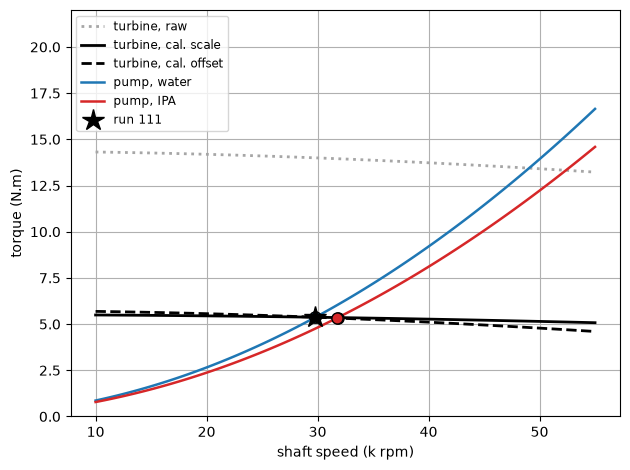

In [19]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

TESTBED = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TESTBED))

import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq
from pyfluids import FluidsList
from otp.propellants.propellant import Propellant
from otp.pump.analysis import Pump
from otp.pump.records import PumpChoices, PumpGeometry, PumpRequirements
from otp.turbine.analysis import Turbine
from otp.turbine.records import TurbineChoices, TurbineGeometry, TurbineInletGas, TurbineRequirements

IN, T_K, P_IN, P_AMB = 0.0254, 293.15, 17.52, 1.01325   # m/inch, K, bar, bar
CD, D_OR = 0.725, 0.004                                  # discharge orifice
N_MEAS = 29806.0                                         # run 111, calibration anchor
RPM = np.linspace(10e3, 55e3, 120)
Q_HI = 2.4e-3            # bracket top; keep below the Lock cavitation cutoff

GEOM = PumpGeometry(d_inlet=1.172217759237197 * IN / 1.2,   # eye, assumed d_1/1.2
                    d_1=1.172217759237197 * IN, d_2=2.7109197023922085 * IN,
                    b_1=0.29305443980929924 * IN, b_2=0.126718478037041 * IN,
                    d_throat=0.2616972455922796 * IN, d_outlet=0.4532729255666586 * IN,
                    d_3=0.0, b_3=0.0, s_ax=0.0)            # unused by point_performance
PUMP = Pump(PumpRequirements(None, 1.2e-3, 760.0), PumpChoices(24e3, 6, 1.0), GEOM)

D_M, BETA, H_BL, A_TH, A_3 = 0.09923005, 20.0, 0.011183178, 5.79405121e-5, 3.55302704e-4
DOA = A_3 / (np.sin(np.radians(BETA)) * np.pi * D_M * H_BL)
TGEOM = TurbineGeometry(D_M, BETA, DOA, 6, H_BL, A_TH, A_3, 0.0, 0.0)
TURB = Turbine(TurbineRequirements(24e3, 24e3), TurbineChoices(D_M, BETA, DOA, 6), TGEOM)
GAS = TurbineInletGas(p01=27.46, T01=970.165, R=537.474, gamma=1.24983, model=None, OF=0.5)


class IPA:                      # CoolProp has no propan-2-ol; 20 C literature values
    class _s: density, kinematic_viscosity, pressure = 785.4, 3.030e-6, 4400.0
    class fluid:
        with_state = staticmethod(lambda *a: IPA._s)   # .pressure only read for p_sat


WATER = Propellant("Water", FluidsList.Water, t_tank=T_K, p_tank=P_IN)
FLUIDS = {"water": (WATER, "tab:blue"), "IPA": (IPA, "tab:red")}


def pump(Q, n, fl):
    return PUMP.point_performance(fl, Q, n, P_IN, T_K, "lock")


def rho(fl):
    return pump(1e-4, 20e3, fl).mdot / 1e-4


def T_pump(n, fl):
    """Torque on the 4 mm orifice line: Q where pump dp drives that flow."""
    A, r = np.pi / 4 * D_OR ** 2, rho(fl)
    f = lambda Q: CD * A * np.sqrt(max(P_IN + pump(Q, n, fl).dp - P_AMB, 0) * 2e5 / r) - Q
    return pump(brentq(f, 1e-7, Q_HI), n, fl).torque


def T_turb(n, scale=1.0, offset=0.0):
    return scale * TURB.point_performance(GAS, rpm=n, p_amb_bar=P_AMB).torque - offset


TP, TT = T_pump(N_MEAS, WATER), T_turb(N_MEAS)          # calibrate turbine on run 111
CASES = [("raw", {}, "0.65", ":"),
         ("cal. scale", dict(scale=TP / TT), "k", "-"),
         ("cal. offset", dict(offset=TT - TP), "k", "--")]

for lab, kw, c, ls in CASES:
    plt.plot(RPM / 1e3, [T_turb(n, **kw) for n in RPM], c, ls=ls, lw=2, label="turbine, " + lab)
for name, (fl, c) in FLUIDS.items():
    tq = np.array([T_pump(n, fl) for n in RPM])
    plt.plot(RPM / 1e3, tq, c, lw=1.8, label="pump, " + name)
    for lab, kw, _, _ in CASES[1:]:                     # crossings
        g = lambda n: T_turb(n, **kw) - T_pump(n, fl)
        s = np.where(np.diff(np.sign([g(n) for n in RPM])))[0]
        if len(s):
            n = brentq(g, RPM[s[0]], RPM[s[0] + 1])
            plt.plot(n / 1e3, T_turb(n, **kw), "o", color=c, mec="k", ms=8, zorder=5)
            print(f"{name:5s} {lab:11s} {n:6.0f} rpm")

plt.plot(N_MEAS / 1e3, TP, "k*", ms=16, zorder=6, label="run 111")
plt.xlabel("shaft speed (k rpm)"); plt.ylabel("torque (N.m)"); plt.ylim(0, 22)
plt.legend(fontsize="small"); plt.grid(True); plt.tight_layout(); plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
water  29800 rpm
IPA    32198 rpm


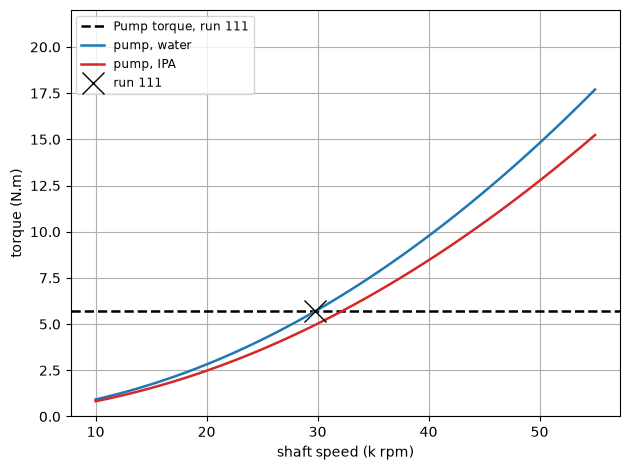

In [20]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

TESTBED = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TESTBED))

import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq
from pyfluids import FluidsList, Input
from otp.propellants.propellant import Propellant
from otp.pump.analysis import Pump
from otp.pump.records import PumpChoices, PumpGeometry, PumpRequirements
from otp.turbine.analysis import Turbine
from otp.turbine.records import TurbineChoices, TurbineGeometry, TurbineInletGas, TurbineRequirements
from otp.core.units import K_TO_C

T_K, P_IN, P_AMB = 293.15, 17.52, 1.01325  #K, bar, bar
N_MEAS = 29800
RPM = np.linspace(10e3, 55e3, 120)
Q_HI = 2.4e-3            # bracket top; keep below the Lock cavitation cutoff

GEOM = PumpGeometry(d_inlet=0.0298 / 1.2,
                    d_1=0.0298, 
                    d_2=0.0689,
                    b_1=0.0074,
                    b_2=0.0032,
                    d_throat=0.0062, 
                    d_outlet=0.0115,
                    d_3=0.0, 
                    b_3=0.0, 
                    s_ax=0.0)            # unused
PUMP = Pump(PumpRequirements(None, 1.2e-3, 760.0), PumpChoices(24e3, 6, 1.0), GEOM)
WATER = Propellant("Water", FluidsList.Water, t_tank=T_K, p_tank=P_IN)
ETHANOL = Propellant("Ethanol", FluidsList.Ethanol, t_tank=T_K, p_tank=P_IN)

class IPA:                      # CoolProp has no propan-2-ol; 20 C literature values
    class _s: density, kinematic_viscosity, pressure = 785.4, 2.66e-6, 4400.0
    class fluid:
        with_state = staticmethod(lambda *a: IPA._s)   # .pressure only read for p_sat

FLUIDS = {"water": (WATER, "tab:blue"), "IPA": (IPA, "tab:red")}
# FLUIDS = {"water": (WATER, "tab:blue"), "ethanol": (ETHANOL, "tab:red")}
def rho(fl):
    return fl.fluid.with_state(Input.pressure(1e5), Input.temperature(T_K + K_TO_C)).density

CD = 0.8
D_OR = 0.004

def pump_torque(n, fl):
    """Torque on the 4 mm orifice line: Q where pump dp drives that flow."""
    A = np.pi / 4 * D_OR ** 2
    A, r = np.pi / 4 * D_OR ** 2, rho(fl)
    f = lambda Q: CD * A * np.sqrt(max(P_IN + PUMP.point_performance(fl, Q, n, P_IN, T_K, "lock").dp - P_AMB, 0) * 2e5 / rho(fl)) - Q
    solved_Q = brentq(f, 1e-7, Q_HI)
    return PUMP.point_performance(fl, solved_Q, n, P_IN, T_K, "lock").torque

test_torque = pump_torque(N_MEAS, WATER)

# horizontal line turbine torque
plt.axhline(test_torque, color="k", lw=1.8, ls="--", label="Pump torque, run 111")
for name, (fl, c) in FLUIDS.items():
    tq = np.array([pump_torque(n, fl) for n in RPM])
    plt.plot(RPM / 1e3, tq, c, lw=1.8, label="pump, " + name)
    g = lambda n: test_torque - pump_torque(n, fl)
    n = brentq(g, 10000, 50000)
    print(f"{name:5s} {n:6.0f} rpm")

plt.plot(N_MEAS / 1e3, test_torque, "kx", ms=16, label="run 111")
plt.xlabel("shaft speed (k rpm)"); plt.ylabel("torque (N.m)"); plt.ylim(0, 22)
plt.legend(fontsize="small"); plt.grid(True); plt.tight_layout(); plt.show()